# Eixo 7 — Limitações Físicas e Mobilidade

**Base:** Behavioral Risk Factor Surveillance System (BRFSS), 2015  
**Pergunta:** pessoas com diabetes e/ou hipertensão relatam mais dificuldade para caminhar ou subir escadas?

Este notebook faz parte do projeto `eda-diabetes` e contém apenas a análise do Eixo 7. Os resultados são associações transversais e autorrelatadas; não demonstram causalidade.

## Preparação e verificação dos dados

O notebook localiza automaticamente o CSV na pasta `dataset` da raiz do projeto, mesmo quando a execução é iniciada dentro da subpasta da análise.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    pass  # O executor de validação injeta uma função display equivalente.

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 14, "axes.labelsize": 11})

nome_dataset = "diabetes_binary_health_indicators_BRFSS2015.csv"
candidatos = [Path(nome_dataset), Path("dataset") / nome_dataset, Path("../../dataset") / nome_dataset]
candidatos += [p / "dataset" / nome_dataset for p in [Path.cwd(), *Path.cwd().parents]]
DATA_PATH = next((p.resolve() for p in candidatos if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset não encontrado. Mantenha a pasta dataset na raiz do projeto.")

df = pd.read_csv(DATA_PATH)
variaveis = [
    "Diabetes_binary", "HighBP", "Smoker", "HvyAlcoholConsump",
    "PhysHlth", "MentHlth", "GenHlth", "DiffWalk"
]
ausentes = [v for v in variaveis if v not in df.columns]
if ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {ausentes}")

resumo_base = pd.DataFrame({
    "Indicador": ["Linhas", "Colunas", "Valores ausentes nas variáveis usadas", "Linhas duplicadas completas"],
    "Valor": [len(df), df.shape[1], int(df[variaveis].isna().sum().sum()), int(df.duplicated().sum())]
})
display(resumo_base)
display(df[variaveis].describe().T.round(2))

,Indicador,Valor
0,Linhas,253680
1,Colunas,22
2,Valores ausentes nas variáveis usadas,0
3,Linhas duplicadas completas,24206


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.43,0.49,0.0,0.0,0.0,1.0,1.0
Smoker,253680.0,0.44,0.50,0.0,0.0,0.0,1.0,1.0
HvyAlcoholConsump,253680.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
PhysHlth,253680.0,4.24,8.72,0.0,0.0,0.0,3.0,30.0
MentHlth,253680.0,3.18,7.41,0.0,0.0,0.0,2.0,30.0
GenHlth,253680.0,2.51,1.07,1.0,2.0,2.0,3.0,5.0
DiffWalk,253680.0,0.17,0.37,0.0,0.0,0.0,0.0,1.0


A ausência de valores nulos nas variáveis selecionadas dispensa imputação. Registros idênticos são mantidos: em uma pesquisa populacional, respostas iguais não significam necessariamente duplicação da mesma pessoa, pois o arquivo não contém identificador individual.

## 2. Funções auxiliares

Para cada par exposição–desfecho binário, calculamos:

- prevalência do desfecho nos grupos exposto e não exposto;
- diferença absoluta em pontos percentuais;
- **PR** (razão de prevalências) e **OR** (odds ratio), com IC95%;
- teste exato de Fisher e V de Cramér.

A PR é a medida principal por ser mais diretamente interpretável em um estudo transversal. OR é apresentada como medida complementar e pode parecer mais extrema quando o desfecho é comum.

In [2]:
def associacao_binaria(dados, exposicao, desfecho, nome_exposicao, nome_desfecho):
    tab = pd.crosstab(dados[exposicao], dados[desfecho]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    a, b = int(tab.loc[1, 1]), int(tab.loc[1, 0])
    c, d = int(tab.loc[0, 1]), int(tab.loc[0, 0])
    n1, n0 = a + b, c + d
    p1, p0 = a / n1, c / n0

    pr = p1 / p0
    se_log_pr = np.sqrt((1 / a) - (1 / n1) + (1 / c) - (1 / n0))
    pr_ic = np.exp(np.log(pr) + np.array([-1, 1]) * 1.96 * se_log_pr)

    or_ = (a * d) / (b * c)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    or_ic = np.exp(np.log(or_) + np.array([-1, 1]) * 1.96 * se_log_or)

    _, p_fisher = stats.fisher_exact([[a, b], [c, d]])
    chi2, _, _, _ = stats.chi2_contingency(tab, correction=False)
    v_cramer = np.sqrt(chi2 / tab.to_numpy().sum())

    return {
        "Exposição": nome_exposicao,
        "Desfecho": nome_desfecho,
        "n expostos": n1,
        "Prev. expostos (%)": 100 * p1,
        "Prev. não expostos (%)": 100 * p0,
        "Diferença (p.p.)": 100 * (p1 - p0),
        "PR": pr,
        "IC95% PR": f"{pr_ic[0]:.2f}–{pr_ic[1]:.2f}",
        "OR": or_,
        "IC95% OR": f"{or_ic[0]:.2f}–{or_ic[1]:.2f}",
        "V de Cramér": v_cramer,
        "p-valor (Fisher)": p_fisher,
    }


def tabela_2x2(dados, exposicao, desfecho, rotulo_exposicao, rotulo_desfecho):
    ct = pd.crosstab(dados[exposicao], dados[desfecho]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100)
    saida = ct.astype(int).astype(str) + " (" + pct.round(2).astype(str) + "%)"
    saida.index = [f"{rotulo_exposicao}: não", f"{rotulo_exposicao}: sim"]
    saida.columns = [f"Sem {rotulo_desfecho}", f"Com {rotulo_desfecho}"]
    return saida

# Eixo 7 — Limitações Físicas e Mobilidade

**Pergunta:** pessoas com diabetes e/ou hipertensão relatam mais dificuldade para caminhar ou subir escadas?

`DiffWalk = 1` indica dificuldade autorrelatada. Primeiro comparamos cada doença separadamente; em seguida, usamos os quatro perfis para observar o acúmulo de condições.

In [3]:
ordem_perfis = ["Nenhum", "Só diabetes", "Só hipertensão", "Ambos"]
condicoes = [
    (df["Diabetes_binary"] == 0) & (df["HighBP"] == 0),
    (df["Diabetes_binary"] == 1) & (df["HighBP"] == 0),
    (df["Diabetes_binary"] == 0) & (df["HighBP"] == 1),
    (df["Diabetes_binary"] == 1) & (df["HighBP"] == 1),
]
df_e6 = df.copy()
df_e6["Perfil_doenca"] = pd.Categorical(
    np.select(condicoes, ordem_perfis, default="Indefinido"),
    categories=ordem_perfis, ordered=True
)
colunas_num = ["Prev. expostos (%)", "Prev. não expostos (%)", "Diferença (p.p.)", "PR", "OR", "V de Cramér"]

In [4]:
analises_e7 = [
    ("Diabetes_binary", "DiffWalk", "Diabetes", "dificuldade para caminhar"),
    ("HighBP", "DiffWalk", "Hipertensão", "dificuldade para caminhar"),
]
resultados_e7 = pd.DataFrame([
    associacao_binaria(df, exp, out, nome_exp, nome_out)
    for exp, out, nome_exp, nome_out in analises_e7
])
exibicao_e7 = resultados_e7.copy()
exibicao_e7[colunas_num] = exibicao_e7[colunas_num].round(3)
exibicao_e7["p-valor (Fisher)"] = exibicao_e7["p-valor (Fisher)"].map(lambda x: "<0,001" if x < 0.001 else f"{x:.3f}".replace(".", ","))
display(exibicao_e7)

print("Tabela 2×2 — diabetes × dificuldade para caminhar")
display(tabela_2x2(df, "Diabetes_binary", "DiffWalk", "Diabetes", "dificuldade"))
print("Tabela 2×2 — hipertensão × dificuldade para caminhar")
display(tabela_2x2(df, "HighBP", "DiffWalk", "Hipertensão", "dificuldade"))

,Exposição,Desfecho,n expostos,Prev. expostos (%),Prev. não expostos (%),Diferença (p.p.),PR,IC95% PR,OR,IC95% OR,V de Cramér,p-valor (Fisher)
0,Diabetes,dificuldade para caminhar,35346,37.122,13.536,23.585,2.742,2.70–2.79,3.771,3.68–3.87,0.218,"<0,001"
1,Hipertensão,dificuldade para caminhar,108829,26.473,9.572,16.901,2.766,2.71–2.82,3.401,3.33–3.48,0.224,"<0,001"


Tabela 2×2 — diabetes × dificuldade para caminhar


,Sem dificuldade,Com dificuldade
Diabetes: não,188780 (86.46%),29554 (13.54%)
Diabetes: sim,22225 (62.88%),13121 (37.12%)


Tabela 2×2 — hipertensão × dificuldade para caminhar


,Sem dificuldade,Com dificuldade
Hipertensão: não,130986 (90.43%),13865 (9.57%)
Hipertensão: sim,80019 (73.53%),28810 (26.47%)


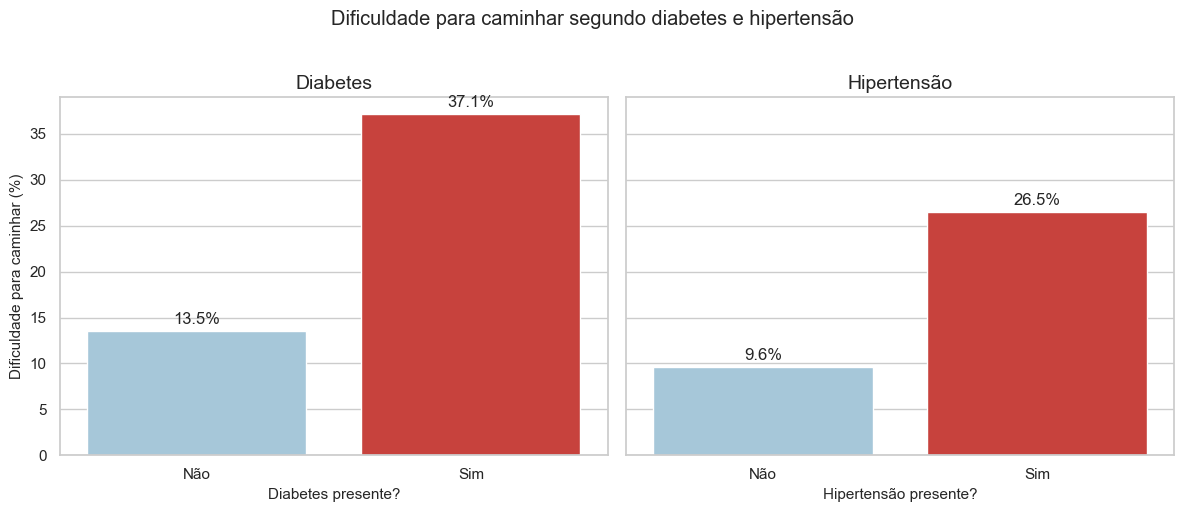

,Perfil_doenca,n,casos,Dificuldade para caminhar (%)
0,Nenhum,136109,11536.0,8.48
1,Só diabetes,8742,2329.0,26.64
2,Só hipertensão,82225,18018.0,21.91
3,Ambos,26604,10792.0,40.57


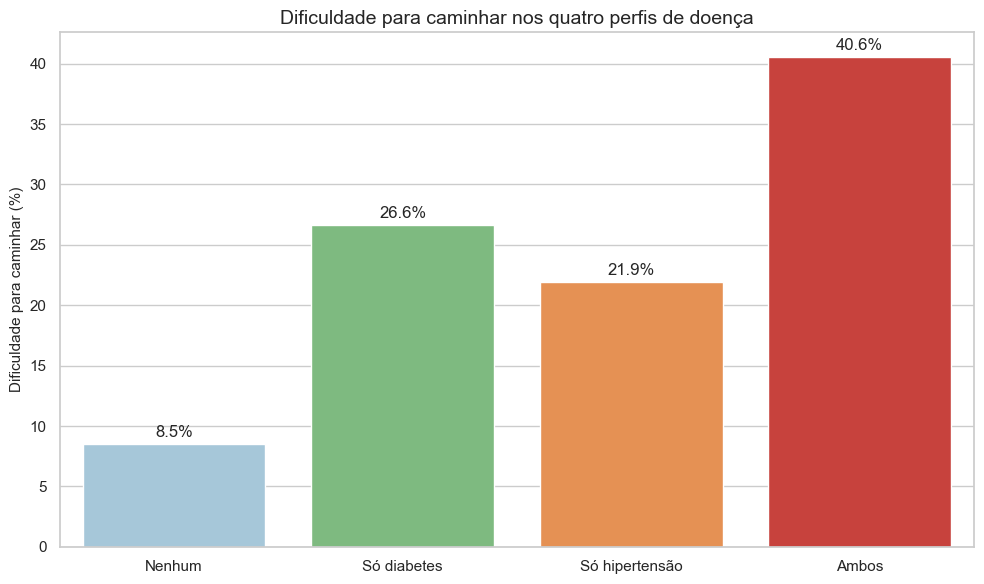

In [5]:
prev_e7 = pd.DataFrame({
    "Condição": ["Diabetes", "Diabetes", "Hipertensão", "Hipertensão"],
    "Grupo": ["Não", "Sim", "Não", "Sim"],
    "Dificuldade para caminhar (%)": [
        100 * df.loc[df["Diabetes_binary"] == 0, "DiffWalk"].mean(),
        100 * df.loc[df["Diabetes_binary"] == 1, "DiffWalk"].mean(),
        100 * df.loc[df["HighBP"] == 0, "DiffWalk"].mean(),
        100 * df.loc[df["HighBP"] == 1, "DiffWalk"].mean(),
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, cond in zip(axes, ["Diabetes", "Hipertensão"]):
    sub = prev_e7[prev_e7["Condição"] == cond]
    sns.barplot(data=sub, x="Grupo", y="Dificuldade para caminhar (%)", hue="Grupo", palette=["#9ecae1", "#de2d26"], legend=False, ax=ax)
    ax.set_title(cond)
    ax.set_xlabel(f"{cond} presente?")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)
fig.suptitle("Dificuldade para caminhar segundo diabetes e hipertensão", y=1.02)
plt.tight_layout()
plt.show()

perfil_diff = (
    df_e6.groupby("Perfil_doenca", observed=False)["DiffWalk"]
    .agg(n="size", casos="sum", prevalencia="mean")
    .reindex(ordem_perfis).reset_index()
)
perfil_diff["Dificuldade para caminhar (%)"] = 100 * perfil_diff["prevalencia"]
display(perfil_diff[["Perfil_doenca", "n", "casos", "Dificuldade para caminhar (%)"]].round(2))

ax = sns.barplot(
    data=perfil_diff, x="Perfil_doenca", y="Dificuldade para caminhar (%)",
    order=ordem_perfis, hue="Perfil_doenca", palette=["#9ecae1", "#74c476", "#fd8d3c", "#de2d26"], legend=False
)
ax.set_title("Dificuldade para caminhar nos quatro perfis de doença")
ax.set_xlabel("")
ax.set_ylabel("Dificuldade para caminhar (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

### Interpretação do Eixo 7

- A dificuldade para caminhar é aproximadamente 2,7 vezes mais prevalente entre pessoas com diabetes e também entre pessoas com hipertensão, quando cada condição é analisada separadamente.
- O perfil combinado reforça um gradiente: o grupo sem as duas condições tem a menor prevalência; os grupos com uma condição ficam em nível intermediário; e o grupo com ambas apresenta a maior frequência de limitação.
- A comparação é bruta. Parte do gradiente pode ser explicada por idade, IMC, doença cardiovascular, AVC e outros fatores relacionados simultaneamente às doenças e à mobilidade.